In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import znet without installing it
sys.path.append(os.path.abspath('..'))

import torch
from znet import *
from torch.func import grad_and_value, vmap

# import thermograph.nodes as tn
# import matplotlib.pyplot as plt
# import numpy as np

print("znet imported successfully")

znet imported successfully


In [2]:
RT = 8.314*300

In [3]:
mu1 = TPowNode(SignalNode(1),-1)
mu2 = TPowNode(SignalNode(2),-1)
RT0 = ConstantNode(RT)


In [4]:
mu1A = TProdNode([RT0, mu1])
mu2A = mu2
mu1B = mu1
mu2B = TProdNode([RT0, mu2])

In [5]:
phaseA = FactorNode(torch.tensor([[1,0],[0,1]]), [mu1A, mu2A], beta_factor = 8.314)
phaseB = FactorNode(torch.tensor([[1,0],[0,1]]), [mu1B, mu2B], beta_factor = 8.314)
system = FactorNode(torch.tensor([[1,0],[0,1]]), [phaseA, phaseB], beta_factor = 1e-8*8.314)

# Grand potential plot

In [6]:
input_tensor, state_order = build_input_tensor(
    {
        "T": torch.tensor(293.15),
        "mu_1": torch.linspace(-10*RT, 10*RT, steps=500),
        "mu_2": torch.linspace(10*RT, -10*RT, steps=500),
    },
    mode ="matched",
)

In [7]:
phaseAb = vmap(phaseA)
phaseBb = vmap(phaseB)
systemb = vmap(system)

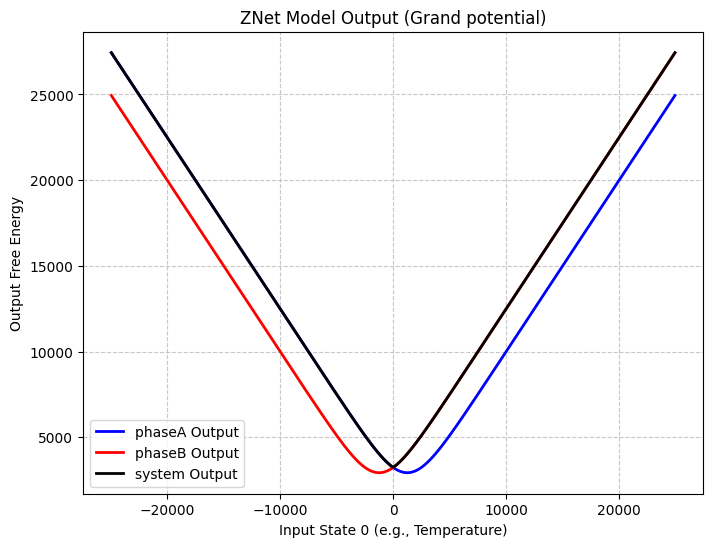

In [8]:
import matplotlib.pyplot as plt


# 3. Plot
plt.figure(figsize=(8, 6))

y_vals = phaseAb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phaseA Output', color='blue', linewidth=2)

y_vals = phaseBb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phaseB Output', color='red', linewidth=2)

y_vals = systemb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='system Output', color='black', linewidth=2)

plt.title("ZNet Model Output (Grand potential)")
plt.xlabel("Input State 0 (e.g., Temperature)")
plt.ylabel("Output Free Energy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Free energy plot

In [9]:
fA = vmap(legendre_transform(phaseA, [1,2]))
fAd, muAd = fA(input_tensor)

fB = vmap(legendre_transform(phaseB, [1,2]))
fBd, muBd = fB(input_tensor)

fsys = vmap(legendre_transform(system, [1,2]))
fsysd, musysd = fsys(input_tensor)

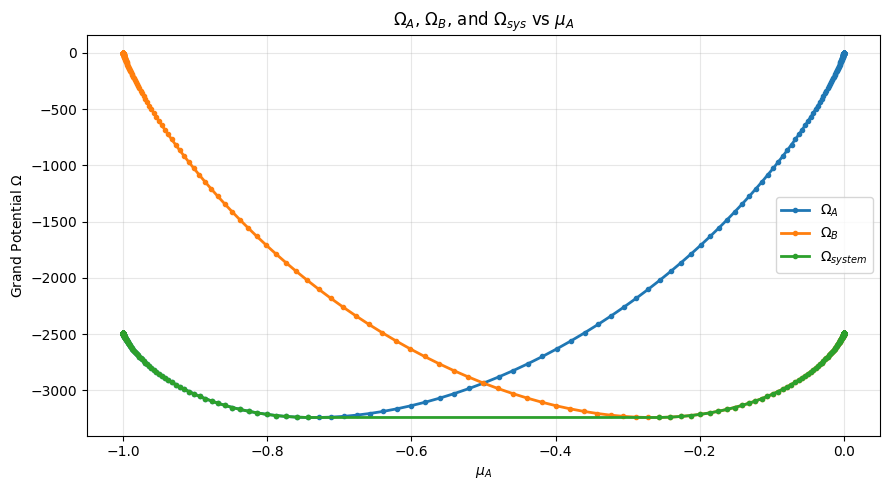

In [10]:

plt.figure(figsize=(9, 5))
plt.plot(muAd[:,1].detach(), -fAd.detach(), label=r'$\Omega_A$', linewidth=2, marker='o', markersize=3)
plt.plot(muBd[:,1].detach(), -fBd.detach(), label=r'$\Omega_B$', linewidth=2, marker='o', markersize=3)
plt.plot(musysd[:,1].detach(), -fsysd.detach(), label=r'$\Omega_{system}$', linewidth=2, marker='o', markersize=3)


plt.xlabel(r'$\mu_A$')
plt.ylabel(r'Grand Potential $\Omega$')
plt.title(r'$\Omega_A$, $\Omega_B$, and $\Omega_{sys}$ vs $\mu_A$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()